# <font color='blue'>Instituto Federal de São Paulo</font>

## <font color='blue'>Fundamentos de Linguagem Python Para Análise de Dados e Data Science</font>

## <font color='blue'>Machine Learning com Scikit-Learn</font>

#### Introdução a Machine Learning
O Aprendizado de Máquina é uma das principais técnicas por trás da Inteligência Artificial que vem revolucionando o mundo. Aqui será apresentado o que é Aprendizado de Máquina. É um assunto extenso que contem quantidades imensas de técnicas, procedimentos e ferramentas que demandariam em um curso especial apenas para estudar este tópico.
Em um projeto de Ciência de Dados, o Aprendizado de Máquina não é obrigatório, ou seja, talvez Machine Learning não resolva todos os problemas existentes. Mas, cada vez mais, as empresas vão descobrindo as vantagens de se usar Machine Learning.

Com Machine Learning, é possível fazer previsões, detectar padrões e anomalias, estudar relacionamento entre variáveis e a partir daí fazer previsões sobre o futuro e outras séries de benefícios. É um tema bastante extenso onde existem  quantidades imensas de algoritmos de Machine Learning. Para cada algoritmo temos várias suposições, várias técnicas, várias ferramentas de uso. Aqui será mostrada uma introdução completa de ponta a ponta, desde a definição do problema de negócio até a entrega do modelo treinado. 

Será apresentado o pacote scikitlearn que é o principal pacote Python para Aprendizado de Máquina. Existem outros pacotes tão bons quanto este como o Pytorch o Tensorflow e outros. O scikitlearn é um dos mais simples e fáceis de se utilizar e ao mesmo tempo é extremamente poderoso. Ele permite criar rapidamente o modelo preditivo capaz de fazer previsões com base no que ele aprendeu através de dados históricos.<br><br>

<b>Aprendizado  Supervisionado</b>

O  aprendizado  supervisionado  é  um  dos  principais  tipos  de  abordagens  em  Machine Learning que veremos na prática agora neste capítulo. Nesse método, o algoritmo é treinado utilizando um conjunto de dados rotulados, em que  cada  exemplo  de  entrada  possui  uma  saída  correspondente,  também  conhecida  como "rótulo" ou "etiqueta". O objetivo é que o modelo aprenda a mapear as entradas para as saídas corretas e, assim, seja capaz de fazer previsões precisas para dados novos e desconhecidos.Durante o processo de treinamento, o algoritmo analisa os exemplos de entrada e ajusta seus parâmetros internos para minimizar a diferença entre as previsões geradas e as saídas corretas (rótulos). Este processo é realizado iterativamente até que o modelo atinja um nível aceitável de precisão.O aprendizado supervisionado pode ser aplicado em dois tipos principais de problemas:<br>
<b>Regressão:</b> quando a saída esperada é um valor contínuo, como a previsão de preços de imóveis ou a estimativa da idade de uma pessoa com base em características específicas.<br>
<b>Classificação:</b> quando a saída esperada é uma categoria ou classe, como por exemplo, determinar se uma pessoa possui diabetes ou não, ou identificar a espécie de uma planta com base em medidas de suas características.<br>
O aprendizado supervisionado é amplamente utilizado em muitas aplicações práticas, como reconhecimento de dígitos escritos à mão, diagnóstico médico e análise de sentimentos em textos, entre outros. Neste capítulo usamos a Linguagem Python em um problema de Regressão.

O primeiro passo é definir o problema de negócio. Sem esta definição é impossível iniciar qualquer projeto de Ciência de Dados.<br><br>
<b>Problema de Negócio:</b>

Usando dados históricos é possível prever o salário de alguém com base no tempo dedicado aos estudos em horas por mês?

Este é um questionamento que pode vir do RH de uma empresa que paga treinamento a seus funcionários que dedicam suas horas para estudar. Com base nisso, será possível calcular o salário da pessoa?

É isso que espera-se que um modelo preditivo de Machine Learning vá responder. 

Para construir um modelo preditivo é necessário matéria prima, ou seja, dados históricos. Se a empresa não os possui, então é impossível criar um modelo de Machine Learning. Se for o caso será necessário começar a coletar os dados históricos.

Será utilizado o mesmo algoritmo utilizado em Regressão Linear onde estudamos o relacionamento entre variáveis em Análise Estatística. Neste caso, criaremos um modelo de Machine Learning para fazer previsões de salários utilizando o mesmo algoritmo mas, com outro foco.

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.13.9


In [2]:
# Imports
# numpy para trabalhar com matemática
import numpy as np
# panda para trabalhar com dados
import pandas as pd
# matplotlib e seaborn para trabalhar com gráficos
import matplotlib.pyplot as plt
import seaborn as sns
# O scikitlearn possui um pacote chamado linear_model que contem o algoritmo 
# de Regressão Linear.
from sklearn.linear_model import LinearRegression
# O scikitlearn possui um pacote chamado model_selection contem o algoritmo 
# train_test_split.
# Este algoritmo tem a função de dividir as amostras de dados em amostras de 
# treino e amostras de teste.
from sklearn.model_selection import train_test_split

## Carregando os Dados

In [3]:
# Carrega o dataset
df = pd.read_csv('dataset.csv')

In [5]:
# O atributo shape mostra o número de linhas e colunas do dataset.
df.shape

(500, 2)

In [8]:
# Mostra o nome das colunas do dataset
df.columns

Index(['horas_estudo_mes', 'salario'], dtype='object')

In [10]:
# O método head() mostra os 5 primeiros registros históricos do dataset.
# A coluna com números em negrito é o índice do dataset. 
# A indexação em Python começa do zero.
df.head()

,horas_estudo_mes,salario
0,57.0,6813.0
1,48.0,6855.0
2,60.0,5801.0
3,73.0,7431.0
4,46.0,5475.0


In [13]:
# Mostra o resumo das variáveis. Não existem variáveis ausentes.
# Cada variável é do tipo float, ou seja, com casas decimais.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   horas_estudo_mes  500 non-null    float64
 1   salario           500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


## Análise Exploratória - Resumo Estatístico

In [14]:
# Verifica se há valores ausentes
# Se existirem valores ausentes, então, deve ser resolvido. 
# Existem várias técnicas para isto.
df.isnull().sum()

horas_estudo_mes    0
salario             0
dtype: int64

In [15]:
# Correlação
# Mostra os Coeficientes de Correlação entre as variáveis.
# O coeficinete de correlação varia de -1 a +1.
# Quanto mais próximo de 1, significa que há forte correlação positiva 
# entre as variáveis.
# Próximo de -1, significa que há correlação negativa entre variáveis.
# Se for igual a zero é porque não há correlação entre as variáveis.
df.corr()

,horas_estudo_mes,salario
horas_estudo_mes,1.000000,0.818576
salario,0.818576,1.000000


In [17]:
# Resumo estatístico do dataset 
# Neste caso, existe uma forte correlação entre a variável preditora 
# (horas_estudo_mes) com a variável alvo (salario).
# Desejamos que a variável preditora explique a variável alvo.
# De acordo com o problema de negócio, o analista deve decidir qual 
# será a variável alvo, neste caso, salário.
df.describe()

,horas_estudo_mes,salario
count,500.000000,500.000000
mean,50.060000,6018.930000
std,14.659406,848.697853
min,1.000000,3664.000000
25%,39.750000,5473.000000
50%,50.000000,6013.500000
75%,60.000000,6542.000000
max,100.000000,9348.000000


In [18]:
# Resumo estatístico da variável preditora
df['horas_estudo_mes'].describe()                        

count    500.000000
mean      50.060000
std       14.659406
min        1.000000
25%       39.750000
50%       50.000000
75%       60.000000
max      100.000000
Name: horas_estudo_mes, dtype: float64

<Axes: xlabel='horas_estudo_mes', ylabel='Count'>

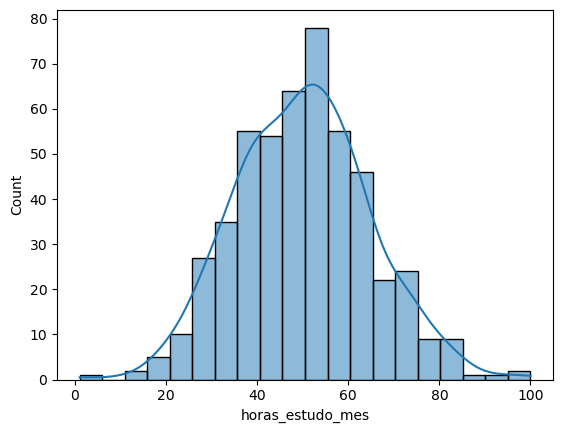

In [19]:
# Histograma da variável preditora
# O formato de sino indica que os dados são normais.
# Os dados normais, a maioria dos valores se concentra ao redor da média, 
# com menos valores nas extremidades.
sns.histplot(data=df, x = "horas_estudo_mes", kde=True)

## Preparação dos Dados

In [20]:
# Prepara a variável de entrada X
# y representa a variável de saída ou variável alvo.
# Isto é uma convenção utilizada em todo o mundo.
# Aqui estamos convertendo a coluna 'horas_estudo_mes' em um array numpy 
# e armazenando a conversão na variável X.
# Isto ocorre porque o algoritmo de regreessão linear do scikirlearn 
# espera receber os dados de entrada no formato de array numpy.
# Já o tensorflow espera receber os dados de entrada no formato de tensor, 
# que é um array multidimensional.
X = np.array(df['horas_estudo_mes'])

In [21]:
# O tipo da variável X será um array numpy
type(X)

numpy.ndarray

In [23]:
print(X)

[[ 57.]
 [ 48.]
 [ 60.]
 [ 73.]
 [ 46.]
 [ 46.]
 [ 74.]
 [ 62.]
 [ 43.]
 [ 58.]
 [ 43.]
 [ 43.]
 [ 54.]
 [ 21.]
 [ 24.]
 [ 42.]
 [ 35.]
 [ 55.]
 [ 36.]
 [ 29.]
 [ 72.]
 [ 47.]
 [ 51.]
 [ 29.]
 [ 42.]
 [ 52.]
 [ 33.]
 [ 56.]
 [ 41.]
 [ 46.]
 [ 41.]
 [ 78.]
 [ 50.]
 [ 34.]
 [ 62.]
 [ 32.]
 [ 53.]
 [ 21.]
 [ 30.]
 [ 53.]
 [ 61.]
 [ 53.]
 [ 48.]
 [ 45.]
 [ 28.]
 [ 39.]
 [ 43.]
 [ 66.]
 [ 55.]
 [ 24.]
 [ 55.]
 [ 44.]
 [ 40.]
 [ 59.]
 [ 65.]
 [ 64.]
 [ 37.]
 [ 45.]
 [ 55.]
 [ 65.]
 [ 43.]
 [ 47.]
 [ 33.]
 [ 32.]
 [ 62.]
 [ 70.]
 [ 49.]
 [ 65.]
 [ 55.]
 [ 40.]
 [ 55.]
 [ 73.]
 [ 49.]
 [ 73.]
 [ 11.]
 [ 62.]
 [ 51.]
 [ 46.]
 [ 51.]
 [ 20.]
 [ 47.]
 [ 55.]
 [ 72.]
 [ 42.]
 [ 38.]
 [ 42.]
 [ 64.]
 [ 55.]
 [ 42.]
 [ 58.]
 [ 51.]
 [ 65.]
 [ 39.]
 [ 45.]
 [ 44.]
 [ 28.]
 [ 54.]
 [ 54.]
 [ 50.]
 [ 46.]
 [ 29.]
 [ 44.]
 [ 45.]
 [ 38.]
 [ 48.]
 [ 56.]
 [ 78.]
 [ 53.]
 [ 54.]
 [ 49.]
 [ 21.]
 [ 50.]
 [ 51.]
 [ 87.]
 [ 47.]
 [ 55.]
 [ 49.]
 [ 32.]
 [ 67.]
 [ 61.]
 [ 62.]
 [ 36.]
 [ 71.]
 [ 29.]
 [ 59.]


In [22]:
# Ajusta o shape de X para conversão de um vetor (1D) em matriz (2D).
# Este ajuste acontece porque para colocar os dados no formato que o 
# scikitlearn espera receber, devemos fazer um ajuste no shape entre -1 e 1.
# O método reshape faz este ajuste, e armazena dos dados novamente em X.
# Na verdade, o ajuste no shape usando .reshape(-1, 1) não está relacionado 
# ao intervalo [-1, 1], mas sim ao formato esperado pelo scikit-learn.
# Quando usamos .reshape(-1, 1), estamos convertendo um vetor unidimensional 
# (1D) em uma matriz 2D com uma única coluna. 
# O -1 diz ao NumPy para calcular automaticamente o número correto de linhas 
# com base no tamanho original do array.
X = X.reshape(-1,1)

In [25]:
# Mostra a variável X convertida em Matriz.
print(X)

[[ 57.]
 [ 48.]
 [ 60.]
 [ 73.]
 [ 46.]
 [ 46.]
 [ 74.]
 [ 62.]
 [ 43.]
 [ 58.]
 [ 43.]
 [ 43.]
 [ 54.]
 [ 21.]
 [ 24.]
 [ 42.]
 [ 35.]
 [ 55.]
 [ 36.]
 [ 29.]
 [ 72.]
 [ 47.]
 [ 51.]
 [ 29.]
 [ 42.]
 [ 52.]
 [ 33.]
 [ 56.]
 [ 41.]
 [ 46.]
 [ 41.]
 [ 78.]
 [ 50.]
 [ 34.]
 [ 62.]
 [ 32.]
 [ 53.]
 [ 21.]
 [ 30.]
 [ 53.]
 [ 61.]
 [ 53.]
 [ 48.]
 [ 45.]
 [ 28.]
 [ 39.]
 [ 43.]
 [ 66.]
 [ 55.]
 [ 24.]
 [ 55.]
 [ 44.]
 [ 40.]
 [ 59.]
 [ 65.]
 [ 64.]
 [ 37.]
 [ 45.]
 [ 55.]
 [ 65.]
 [ 43.]
 [ 47.]
 [ 33.]
 [ 32.]
 [ 62.]
 [ 70.]
 [ 49.]
 [ 65.]
 [ 55.]
 [ 40.]
 [ 55.]
 [ 73.]
 [ 49.]
 [ 73.]
 [ 11.]
 [ 62.]
 [ 51.]
 [ 46.]
 [ 51.]
 [ 20.]
 [ 47.]
 [ 55.]
 [ 72.]
 [ 42.]
 [ 38.]
 [ 42.]
 [ 64.]
 [ 55.]
 [ 42.]
 [ 58.]
 [ 51.]
 [ 65.]
 [ 39.]
 [ 45.]
 [ 44.]
 [ 28.]
 [ 54.]
 [ 54.]
 [ 50.]
 [ 46.]
 [ 29.]
 [ 44.]
 [ 45.]
 [ 38.]
 [ 48.]
 [ 56.]
 [ 78.]
 [ 53.]
 [ 54.]
 [ 49.]
 [ 21.]
 [ 50.]
 [ 51.]
 [ 87.]
 [ 47.]
 [ 55.]
 [ 49.]
 [ 32.]
 [ 67.]
 [ 61.]
 [ 62.]
 [ 36.]
 [ 71.]
 [ 29.]
 [ 59.]


In [26]:
# Preparando a variável alvo
# Filtrando a variável salário e armazenando em y.
y = df['salario']

In [27]:
# Mostrando a variável alvo y
print(y)

0      6813.0
1      6855.0
2      5801.0
3      7431.0
4      5475.0
        ...  
495    6259.0
496    6099.0
497    6170.0
498    5064.0
499    5236.0
Name: salario, Length: 500, dtype: float64


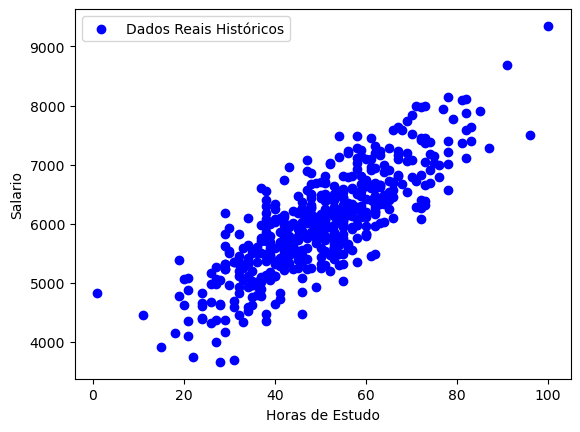

In [33]:
# Gráfico de dispersão entre X e y
plt.scatter(X, y, color='blue', label = 'Dados Reais Históricos')
plt.xlabel('Horas de Estudo')
plt.ylabel('Salario')
plt.legend()
plt.show()

#### Explicação do Gráfico de Dispersão
À medida em que se aumenta as horas de estudo, aumenta-se o salário do funcionário, confirmando a correlação entre as variáveis de entrada (horas de estudo) e saída de dados (salário).

Dependendo de como os dados estarão organizados, deveremos fazer organização e padronização dos dados que não é o caso deste exemplo.

#### Divisão dos Dados em Treino e Teste
Neste exemplo temos 500 regsitros de dados, ou seja, 500 salário e 500 horas de estudo.
Se colocássemos todos os 500 registros para treinamento do algoritmo, como iremos saber se o algoritmo aprendeu alguma coisa?

É por isto que temos que dividir o dados em dados de treino e dados de teste. Assim, X_treino são dados de entrada para treinar e X_teste são dados de entrada para testar. O mesmo ocorre com os dados de saída y_treino e y_teste.

O objeto train_test_split faz a divisão dos dados, neste exemplo, o tamanho dos dados de teste é de 20% (test_size=0.2), por consguinte, o tamanho dos dados de treino é 80%. Basta definir o tamanho dos dados de teste porque o restante serão dados de treino.

O parâmetro random_state = 42 define que para cada vez que treinarmos novamente o algoritmo, novos dados de treino e teste sejam selecionados, ou seja, cada treino serão com dados diferentes entre as 500 amostras.

Isto significa que 80% dos 500 registros serão destinados ao algoritmo para treinamento. Neste treinamento o algoritmo estabelece as relações entre as variáveis de entrada e saída de dados. Depois de treinado, submetemos o algoritmo aos dados de teste que não passaram pelo treinamento. Assim, poderemos verificar a eficiência do algoritmo.

In [34]:
# Dividir dados em treinamento e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state= 42)

In [35]:
# Veja que a quantidade de registros para treino da variável de entrada 
# é 400(80%)
# Observe que o shape possui 400 linhas e 1 coluna, ou seja, X_treino é uma 
# matriz (400 linhas e 1 coluna)
# conforme reshape feito anteriormente.
X_treino.shape

(400, 1)

In [36]:
# Veja que a quantidade de registros para teste da variável de entrada é 100 (20%)
# Observe que o shape possui 100 linhas e 1 coluna, ou seja, X_teste é uma 
# matriz (100 linhas e 1 coluna)
X_teste.shape

(100, 1)

In [37]:
# Veja que a quantidade de registros para treino da variável de saída é 400(80%)
# Observe que y_treino possui 400 linhas e não possui colunas.
# Isso acontece porque a variável y é um vetor numpy e não uma matriz.
# Não fizemos reshape na variável y, apenas na variável X, por imposição da 
# sintaxe do skilearn.
y_treino.shape

(400,)

In [38]:
# Veja que a quantidade de registros para teste da variável de saída é 100 (20%)
# Ou seja, um vetor de 100 linhas.
print(y_treino)

249    5597.0
433    5451.0
19     5326.0
322    6549.0
332    5548.0
        ...  
106    7013.0
270    7454.0
348    5131.0
435    5799.0
102    6185.0
Name: salario, Length: 400, dtype: float64


## Modelagem Preditiva (Machine Learning)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [39]:
# Cria o modelo de regressão linear simples
# Nesta linha, modelo é um objeto que pertence à classe LinearRegression() 
# do pacote sklearn.
# Então o objeto modelo é uma instância da classe LinearRegression().
modelo = LinearRegression()

In [42]:
# Treinamento do modelo
# A classe LinearRegression() possui o método fit que gera o modelo de 
# Machine Learning.
# Na geração do modelo utiliza-se apenas os dados de treino das variáveis X e y.

modelo.fit(X_treino, y_treino)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


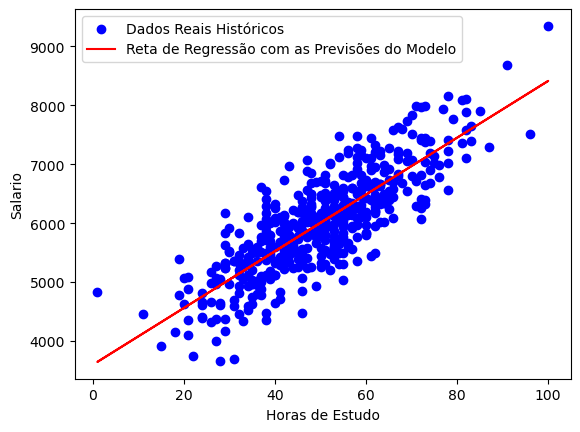

In [44]:
# Visualiza a reta de regressão linear (previsões) e os dados reais usados 
# no treinamento.
# Dados Históricos originais de X e y inseridos no método scatter 
# (gráfico de dispersão)
plt.scatter(X, y, color = 'blue', label = 'Dados Reais Históricos')
plt.plot(X, modelo.predict(X), color = 'red', label = 'Reta de Regressão com as Previsões do Modelo')
plt.xlabel('Horas de Estudo')
plt.ylabel('Salario')
plt.legend()
plt.show()

In [46]:
# Avalia o modelo nos dados de teste
# Avalia o modelo nos dados de teste
score = modelo.score(X_teste, y_teste)
print(f'Coeficiente R²: {score:.2f}')

Coeficiente R²: 0.59


#### Explicação do Modelo
A fórmula de cálculo do modelo de Regressão Linear é <b>y = w0 + w1x</b>, onde, <b>w0</b> e <b>w1</b> são os coeficientes calculados pelo modelo de Machine Learning para Regressão Linear. Inicialmente não temos os coeficientes <b>w0</b> e <b>w1</b> e o modelo os calculou. Mas, fornecemos os dados para y e x.
Aqui se encerra o trabalho do Cientista de Dados.

<b>Atenção:</b> Machine Learning é matemática pura!

In [47]:
# Intercepto - parâmetro w0
modelo.intercept_

np.float64(3596.783724372753)

In [48]:
# Slope - parâmetro w1
modelo.coef_

array([48.18185277])

Algoritmo de Regressão Linear:

![IFSP](reglinear.png)

## Deploy do Modelo

Usaremos o modelo para prever o salário com base nas horas de estudo.

In [49]:
# Define um novo valor para horas de estudo

horas_estudo_novo = np.array([[48]])
# Faz previsão com o modelo treinado
salario_previsto = modelo.predict(horas_estudo_novo)
print(f"Se você estudar ", horas_estudo_novo, " horas por mês, seu sálario pode ser = ", salario_previsto)


Se você estudar  [[48]]  horas por mês, seu sálario pode ser =  [5909.5126574]


In [50]:
# Mesmo resultado anterior usando os parâmetros (coeficientes) aprendidos pelo modelo
# y_novo = w0 + w1 * X
salario = modelo.intercept_ + (modelo.coef_ * horas_estudo_novo)
print(salario)


[[5909.5126574]]


In [51]:
# Define um novo valor para horas de estudo
horas_estudo_novo = np.array([[65]])


# Faz previsão com o modelo treinado
salario_previsto = modelo.predict(horas_estudo_novo)
print(f"Se você estudar ", horas_estudo_novo, " horas por mês, seu sálario pode ser = ", salario_previsto)




Se você estudar  [[65]]  horas por mês, seu sálario pode ser =  [6728.60415452]


In [52]:
# Define um novo valor para horas de estudo
horas_estudo_novo = np.array([[83]])
salario_previsto = modelo.predict(horas_estudo_novo)
print(f"Se você estudar ", horas_estudo_novo, " horas por mês, seu sálario pode ser = ", salario_previsto)

# Faz previsão com o modelo treinado




Se você estudar  [[83]]  horas por mês, seu sálario pode ser =  [7595.8775044]


# Fim